## Boston House Pricing Prediction

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Boston Dataset.csv")
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.drop(columns=['Unnamed: 0'], axis=0, inplace=True)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### Statistical Dataset Info

In [5]:
df.shape

(506, 14)

In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Data pre-processing

In [8]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

In [9]:
# missing values row

df[df.isnull().any(axis=1)]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv


In [10]:
# Identifying the unique number of values in the dataset

df.nunique()

crim       504
zn          26
indus       76
chas         2
nox         81
rm         446
age        356
dis        412
rad          9
tax         66
ptratio     46
black      357
lstat      455
medv       229
dtype: int64

### Data analysis with sub-plot

In [11]:
# let create a sub-dataset with factors associated with population demographics

features = df.loc[0:,('crim', 'dis', 'rad', 'ptratio', 'lstat')]

features

,crim,dis,rad,ptratio,lstat
0,0.00632,4.0900,1,15.3,4.98
1,0.02731,4.9671,2,17.8,9.14
2,0.02729,4.9671,2,17.8,4.03
3,0.03237,6.0622,3,18.7,2.94
4,0.06905,6.0622,3,18.7,5.33
...,...,...,...,...,...
501,0.06263,2.4786,1,21.0,9.67
502,0.04527,2.2875,1,21.0,9.08
503,0.06076,2.1675,1,21.0,5.64
504,0.10959,2.3889,1,21.0,6.48


In [12]:
features.mean()

crim        3.613524
dis         3.795043
rad         9.549407
ptratio    18.455534
lstat      12.653063
dtype: float64

In [13]:
features.std()

crim       8.601545
dis        2.105710
rad        8.707259
ptratio    2.164946
lstat      7.141062
dtype: float64

In [14]:
features.var()

crim       73.986578
dis         4.434015
rad        75.816366
ptratio     4.686989
lstat      50.994760
dtype: float64

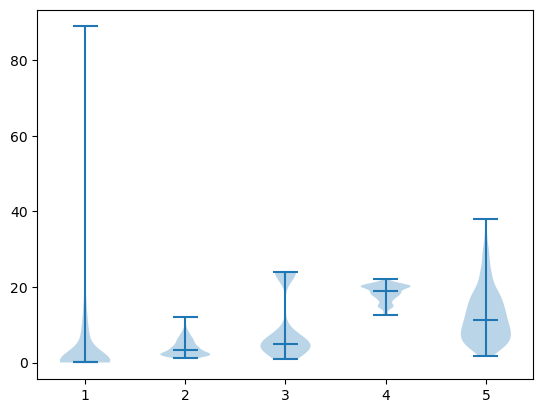

In [15]:
plt.violinplot(features, showmedians=True)
plt.show()

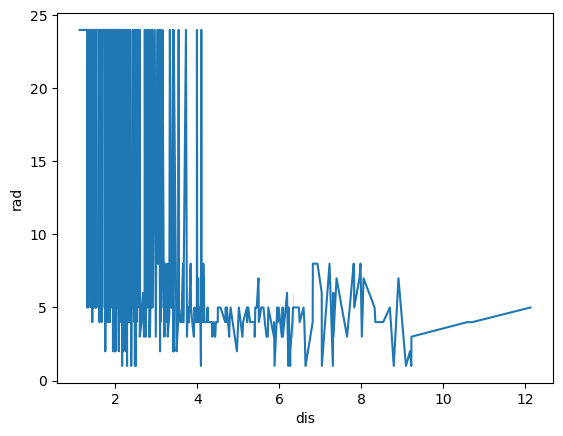

In [16]:
# employment centres, highway connectivity

sns.lineplot(x='dis',y='rad',data=features)
plt.show()

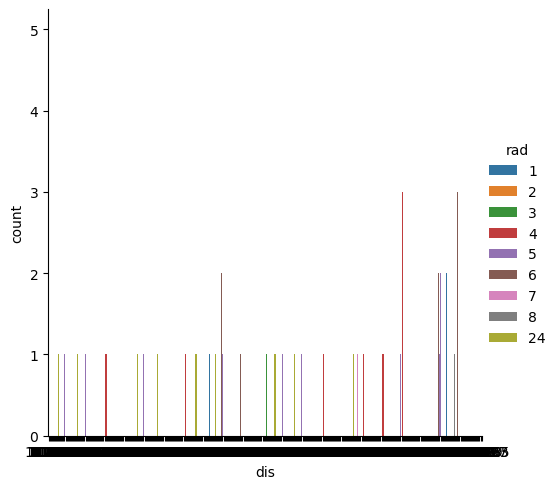

In [17]:
sns.catplot(x ="dis", hue ="rad", kind ="count", data = features)
plt.show()

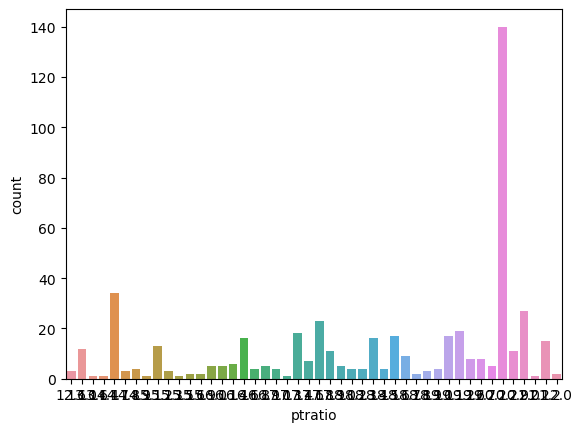

In [18]:
sns.countplot(x='ptratio', data=features)
plt.show()

### Exploratory Data Analysis

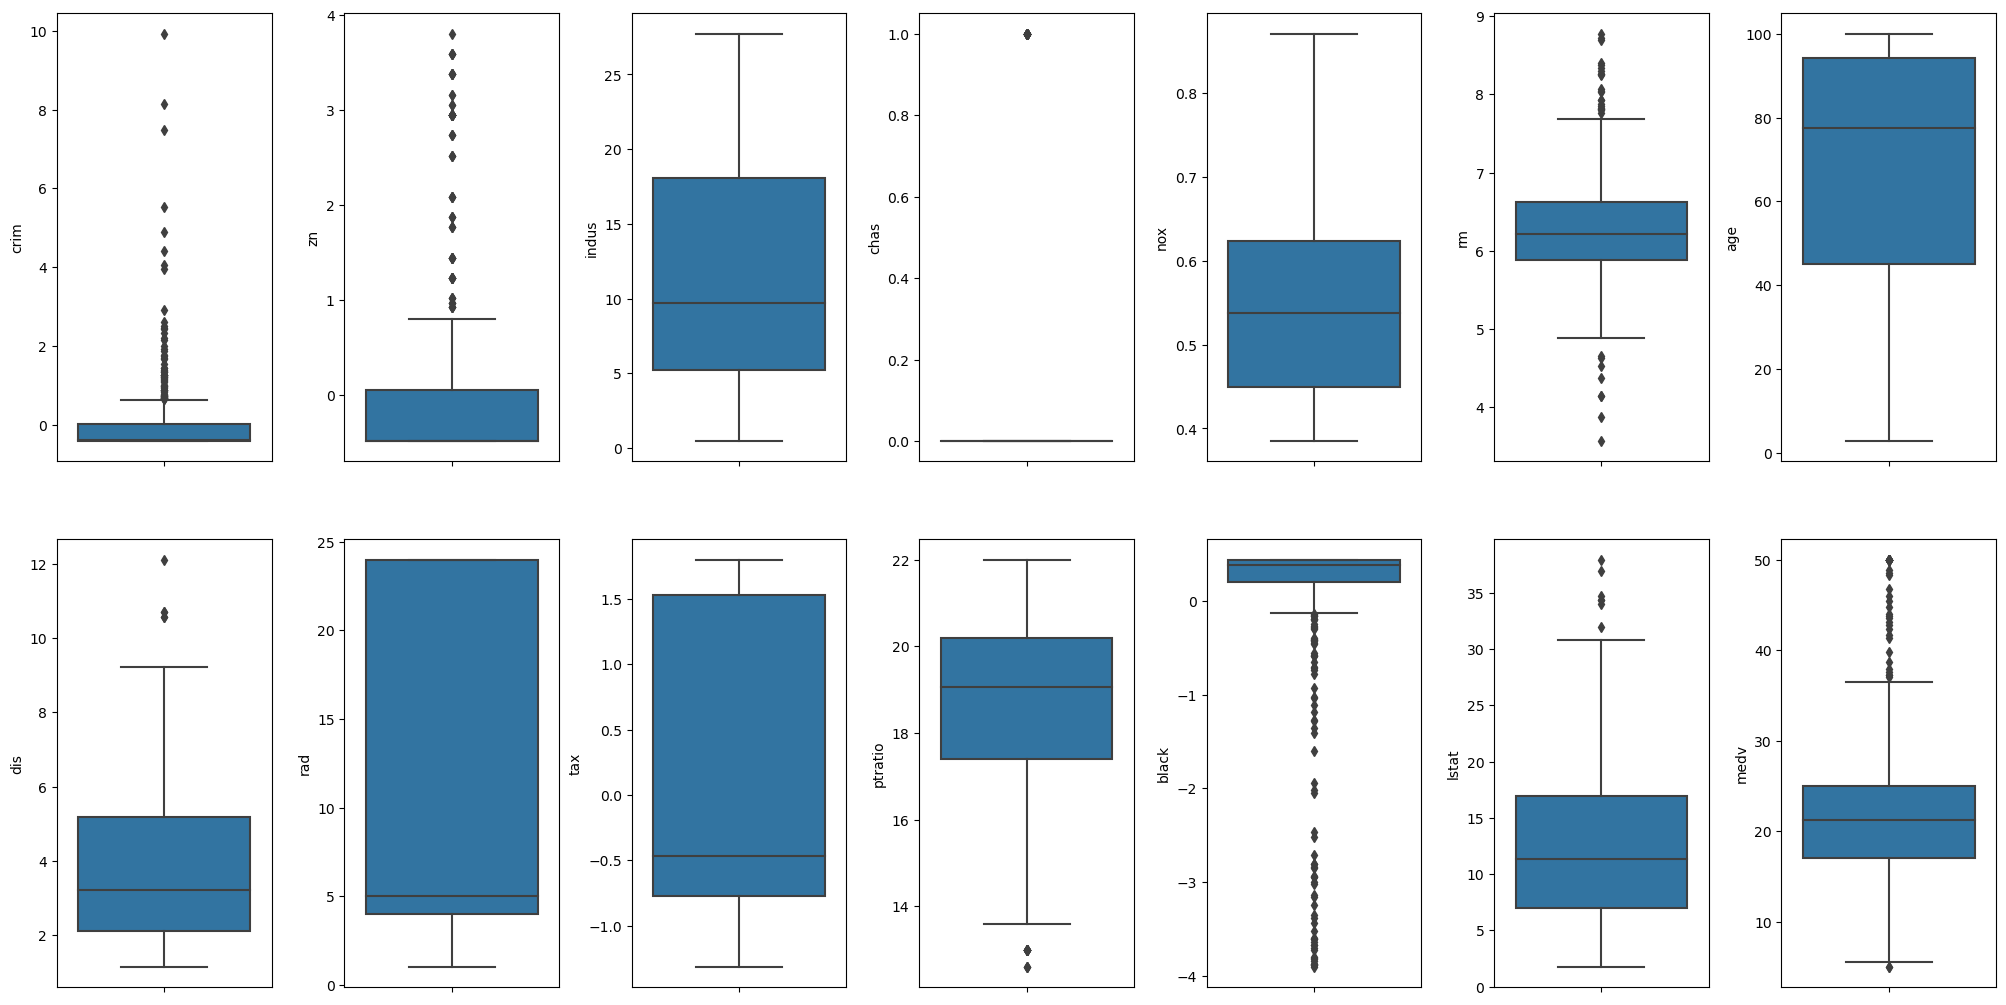

In [34]:
# create box plots for all atributes to identify the outliers

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
ax = ax.flatten()

for col, value in df.items():
    sns.boxplot(y=col, data=df, ax=ax[index])
    index += 1

# hyper-parameter tuning to display graph properly

plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0) 

# major outlier cols = crim, xn, black. we have to apply normalisation techniques to correct the outliers 


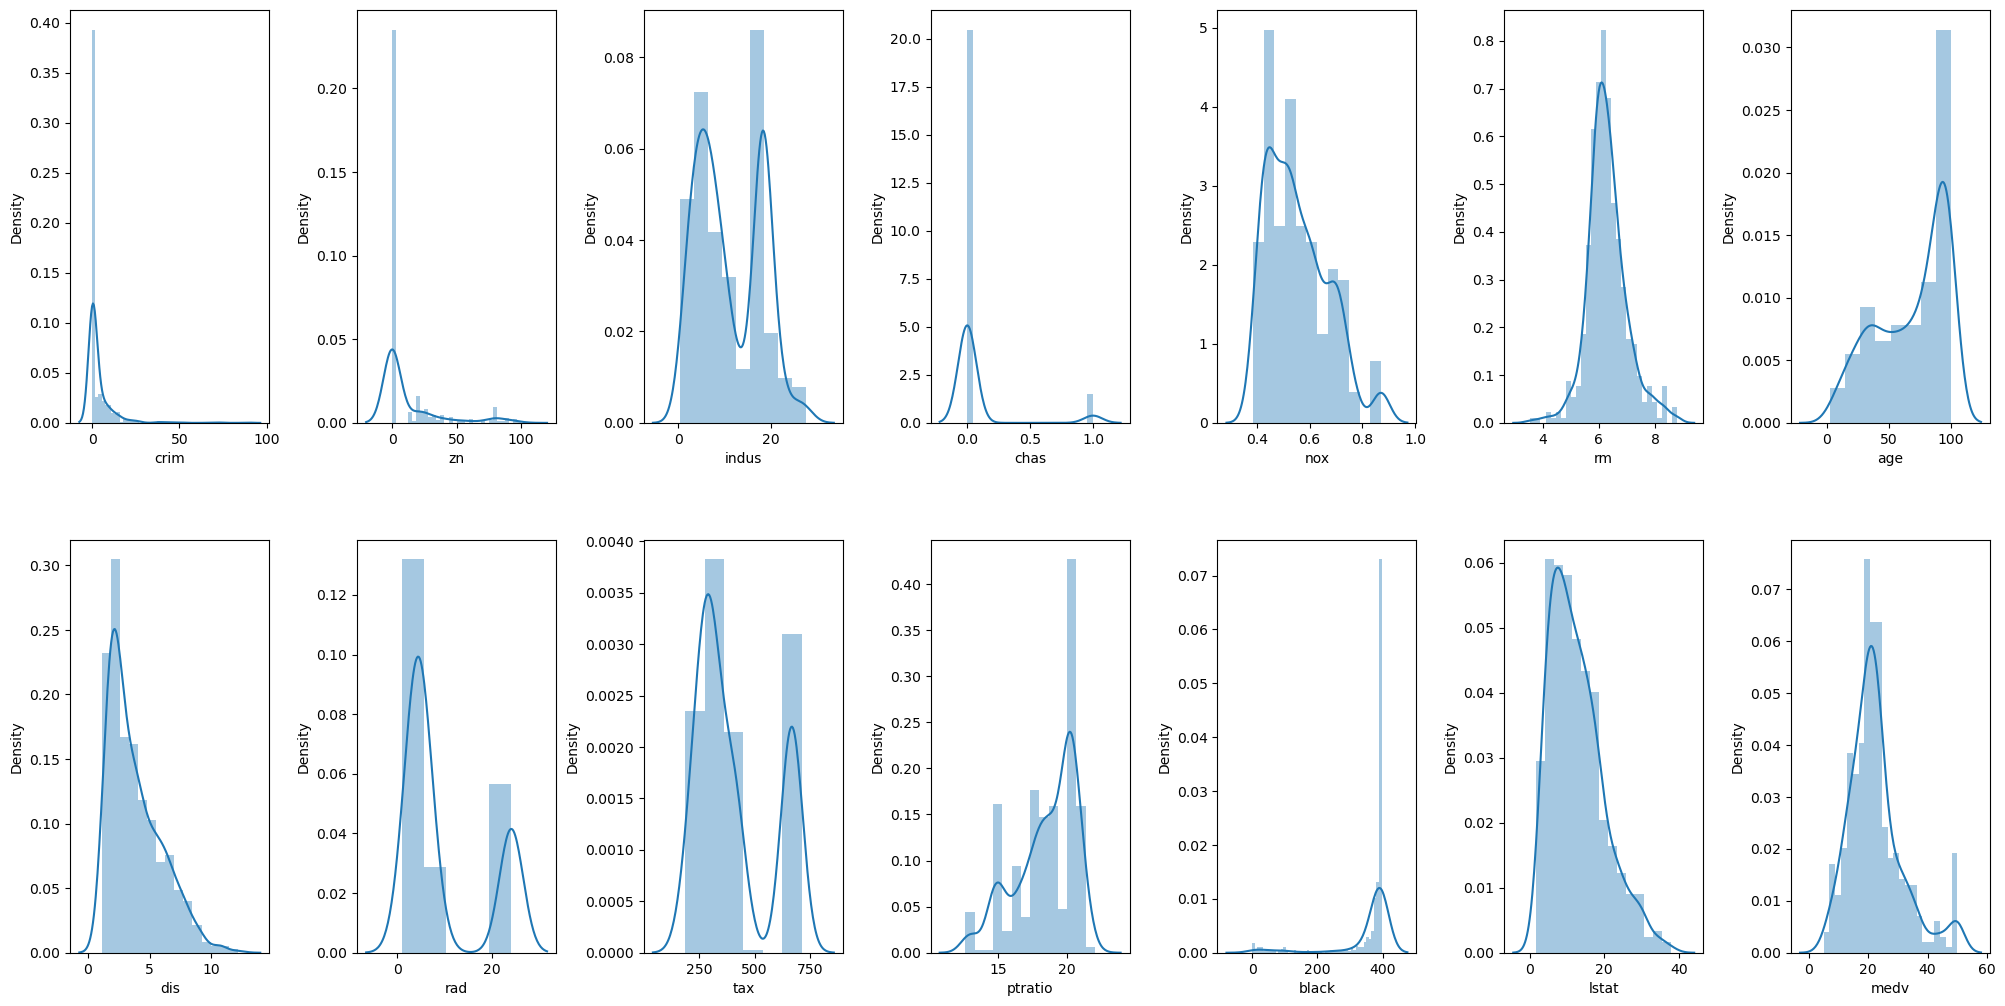

In [20]:
# lets check the data distribution with dist plot

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
ax = ax.flatten()

for col, value in df.items():
    sns.distplot(value, ax=ax[index])
    index += 1
plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

### Min-Max Normalization

In [21]:
# there are few columns with outliers, we need to normalise data with min-max method

cols = ['crim', 'zn', 'tax', 'black']

for col in cols:
    # find minimum value and maximum value of the columns
    minimum = min(df[col])
    maximum = max(df[col])
    data_norm = ((df - df.min()) / (df.max() - df.min())) * 10 + 1

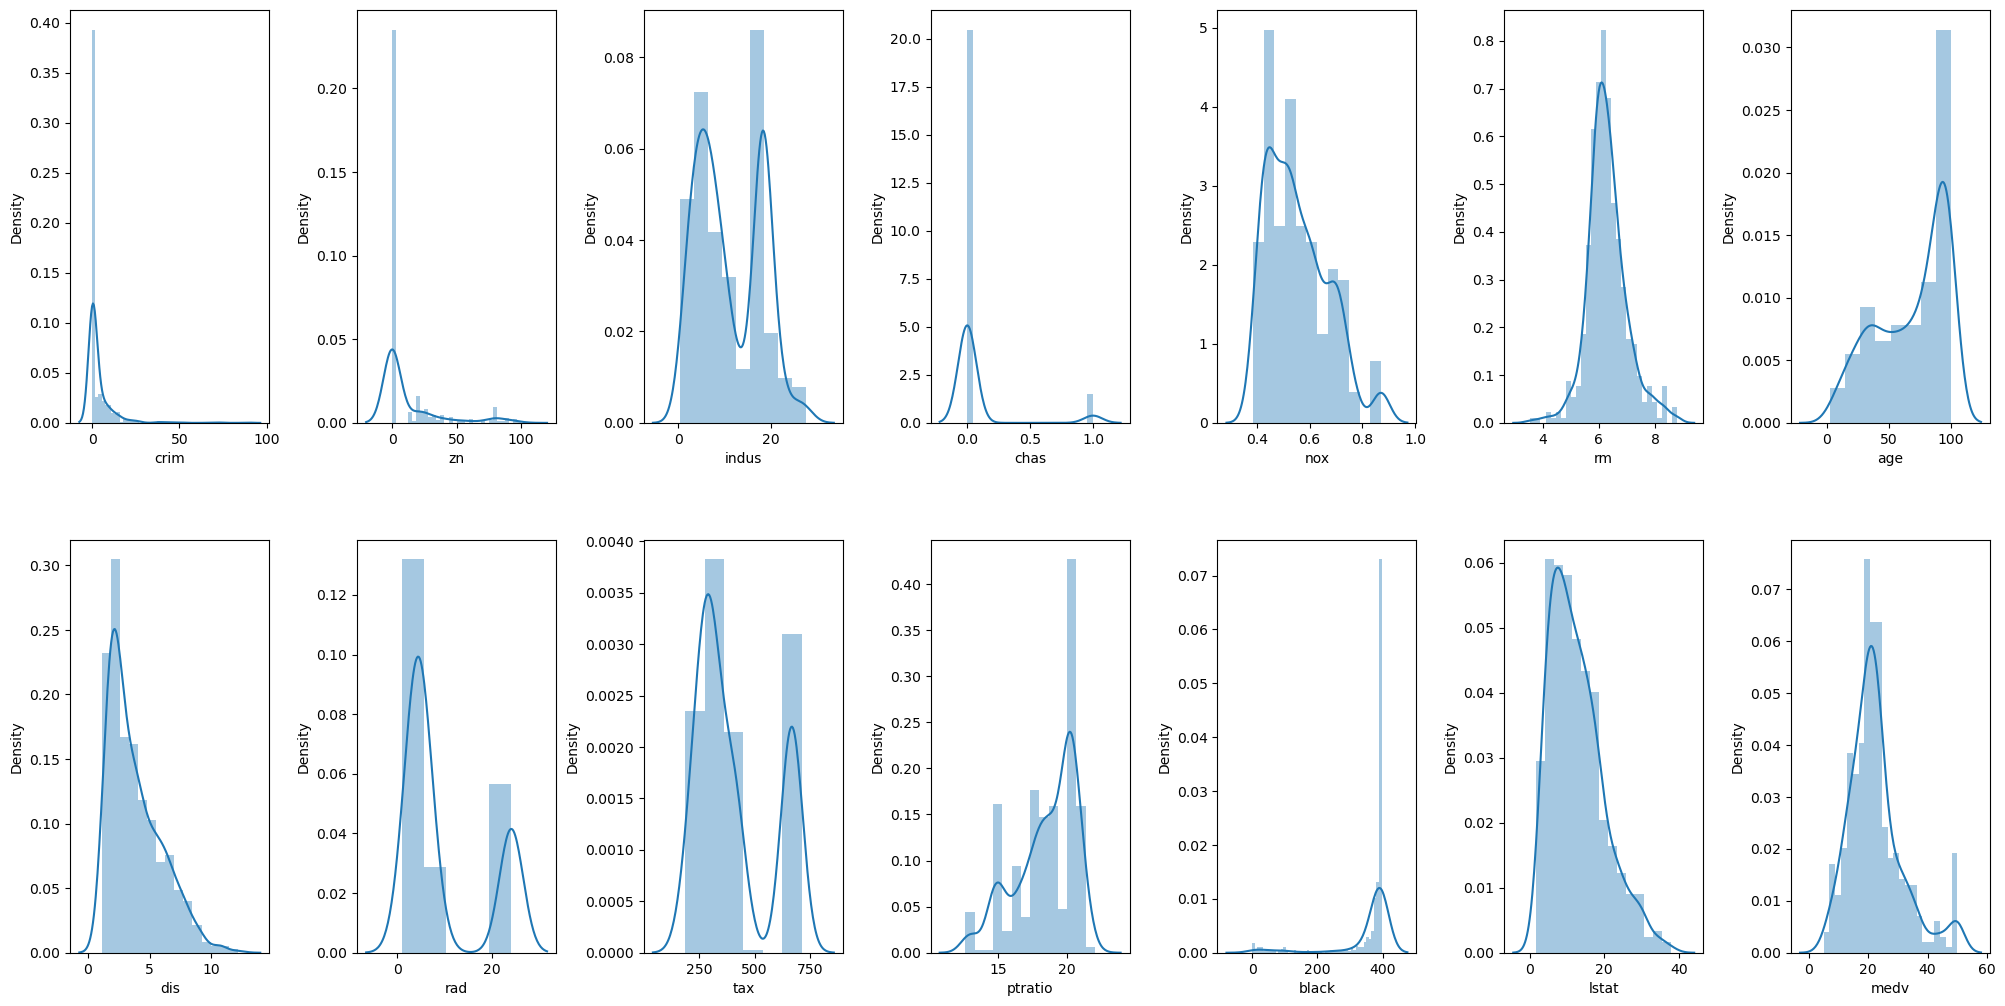

In [22]:
# lets check the columns to view the changes after applied min-max normalization

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
ax = ax.flatten()

for col, value in df.items():
    sns.distplot(value, ax=ax[index])
    index += 1
plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

In [23]:
# min-max normalisation shows little changes, we will now use the standard scaling method to normalise the data

from sklearn import preprocessing
scalar = preprocessing.StandardScaler()

# fit our data
scaled_cols = scalar.fit_transform(df[cols])
scaled_cols = pd.DataFrame(scaled_cols, columns=cols)
scaled_cols.head()

,crim,zn,tax,black
0,-0.419782,0.284830,-0.666608,0.441052
1,-0.417339,-0.487722,-0.987329,0.441052
2,-0.417342,-0.487722,-0.987329,0.396427
3,-0.416750,-0.487722,-1.106115,0.416163
4,-0.412482,-0.487722,-1.106115,0.441052


In [24]:
for col in cols:
    df[col] = scaled_cols[col]

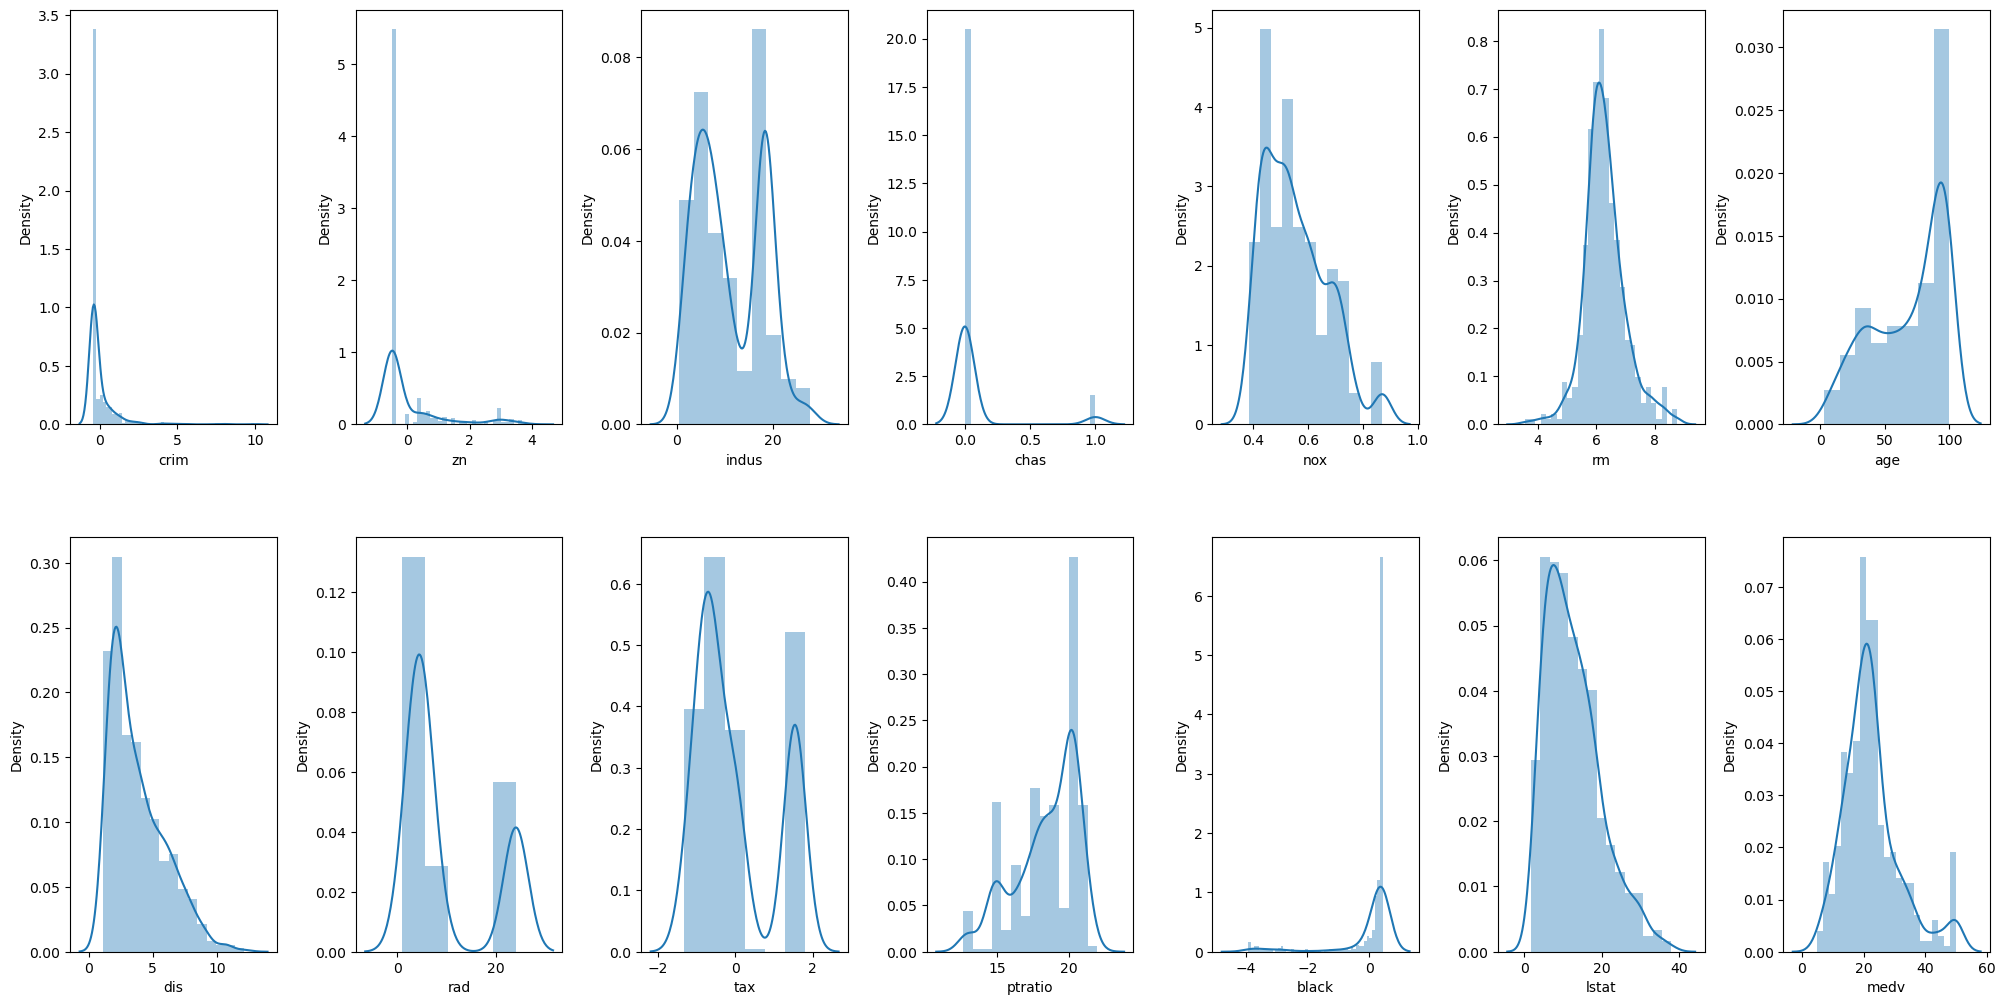

In [25]:
# after applied scalar method to normalise data, we see little changes in the data normalisation

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
ax = ax.flatten()

for col, value in df.items():
    sns.distplot(value, ax=ax[index])
    index += 1
plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

### Correlation Matrix

<AxesSubplot:>

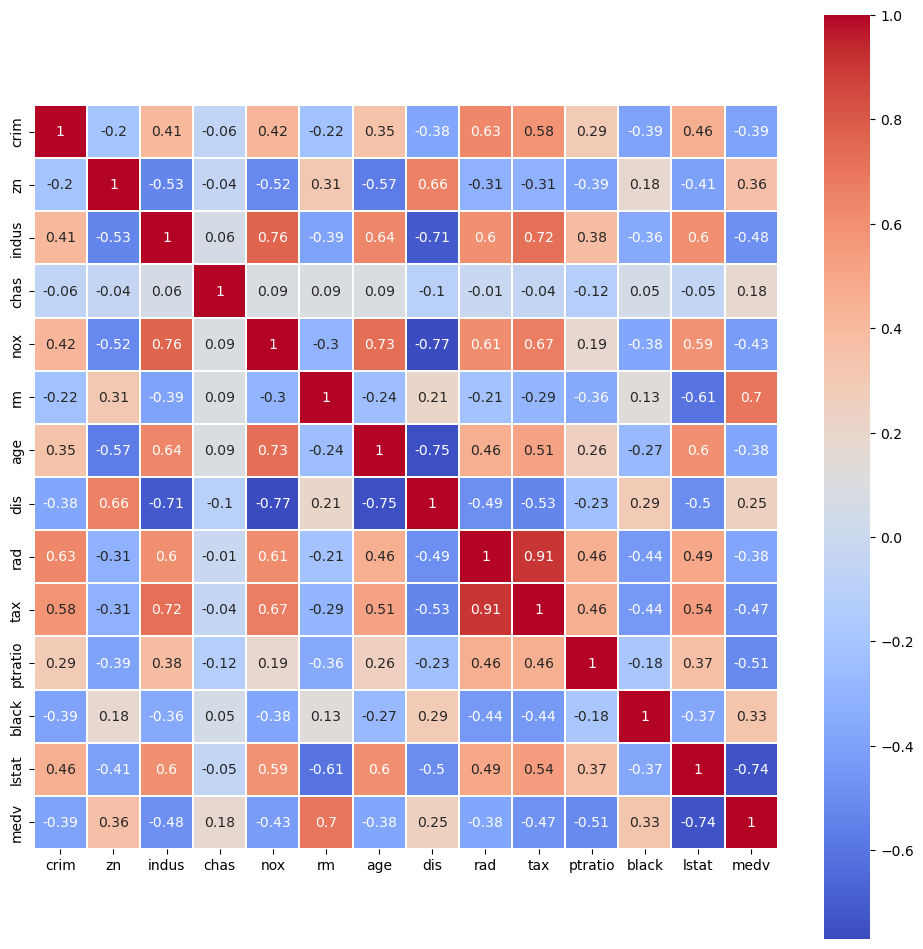

In [26]:
plt.figure(figsize=(12,12))
sns.heatmap(data=df.corr().round(2),annot=True,cmap='coolwarm',linewidths=0.2,square=True)

In [27]:
# these features show good correlation with our predictive variable House Price- (MEDV)

df_corr = df[['rm','tax','ptratio','lstat','medv']]
df_corr.head()

,rm,tax,ptratio,lstat,medv
0,6.575,-0.666608,15.3,4.98,24.0
1,6.421,-0.987329,17.8,9.14,21.6
2,7.185,-0.987329,17.8,4.03,34.7
3,6.998,-1.106115,18.7,2.94,33.4
4,7.147,-1.106115,18.7,5.33,36.2


In [28]:
df_corr.describe().round(2)

,rm,tax,ptratio,lstat,medv
count,506.00,506.00,506.00,506.00,506.00
mean,6.28,-0.00,18.46,12.65,22.53
std,0.70,1.00,2.16,7.14,9.20
min,3.56,-1.31,12.60,1.73,5.00
25%,5.89,-0.77,17.40,6.95,17.02
50%,6.21,-0.46,19.05,11.36,21.20
75%,6.62,1.53,20.20,16.96,25.00
max,8.78,1.80,22.00,37.97,50.00


### Input Split

In [29]:
X = df.drop(columns=['medv', 'rad'], axis=1)
y = df['medv']

### ML model training

In [30]:
# split input and output dataset, evaluation metric - Mean squared error

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
def train(model, X, y):
    # train the model
    x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)
    model.fit(x_train, y_train)
    
    # predict the training set
    pred = model.predict(x_test)
    
    # perform cross-validation
    cv_score = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
    cv_score = np.abs(np.mean(cv_score))
    
    print("Model Report")
    print("MSE:",mean_squared_error(y_test, pred))
    print('CV Score:', cv_score)

Model Report
MSE: 10.280455377952753
CV Score: 21.87273632552902


<AxesSubplot:title={'center':'Feature Importance'}>

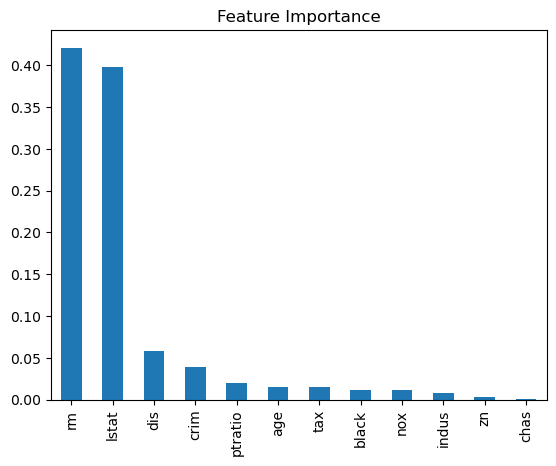

In [31]:
# model - Random forest

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
train(model, X, y)
coef = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
coef.plot(kind='bar', title='Feature Importance')

Model Report
MSE: 10.229776363874551
CV Score: 18.766198044819188


<AxesSubplot:title={'center':'Feature Importance'}>

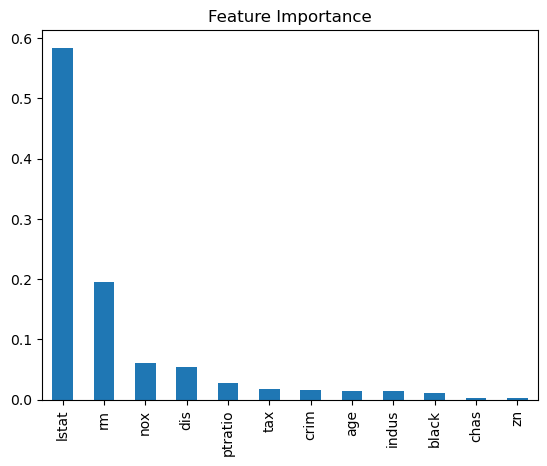

In [32]:
import xgboost as xgb
model = xgb.XGBRegressor()
train(model, X, y)
coef = pd.Series(model.feature_importances_, X.columns).sort_values(ascending=False)
coef.plot(kind='bar', title='Feature Importance')